In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
df = pd.read_csv("Hotel Management Booking Data.csv")
df.head()   #1st five rows

,Booking ID,Hotel,Booking Date,Arrival Date,Lead Time,Nights,Guests,Distribution Channel,Customer Type,Country,Deposit Type,Avg Daily Rate,Status,Status Update,Cancelled (0/1),Revenue,Revenue Loss,Unnamed: 17
0,1,Resort,2014-07-24,2015-07-01,342,0,2,Direct,Transient,Portugal,No Deposit,$0.00,Check-Out,2015-07-01,0,$0.00,$0.00,NaN
1,2,Resort,2013-06-24,2015-07-01,737,0,2,Direct,Transient,Portugal,No Deposit,$0.00,Check-Out,2015-07-01,0,$0.00,$0.00,NaN
2,3,Resort,2015-06-24,2015-07-01,7,1,1,Direct,Transient,United Kingdom,No Deposit,$75.00,Check-Out,2015-07-02,0,$75.00,$0.00,NaN
3,4,Resort,2015-06-18,2015-07-01,13,1,1,Corporate,Transient,United Kingdom,No Deposit,$75.00,Check-Out,2015-07-02,0,$75.00,$0.00,NaN
4,5,Resort,2015-06-17,2015-07-01,14,2,2,Online Travel Agent,Transient,United Kingdom,No Deposit,$98.00,Check-Out,2015-07-03,0,$196.00,$0.00,NaN


In [3]:
df.tail()  #last five rows

,Booking ID,Hotel,Booking Date,Arrival Date,Lead Time,Nights,Guests,Distribution Channel,Customer Type,Country,Deposit Type,Avg Daily Rate,Status,Status Update,Cancelled (0/1),Revenue,Revenue Loss,Unnamed: 17
119385,119386,City,2017-08-07,2017-08-30,23,7,2,Offline Travel Agent,Transient,Belgium,No Deposit,$96.14,Check-Out,2017-09-06,0,$672.98,$0.00,NaN
119386,119387,City,2017-05-21,2017-08-31,102,7,3,Online Travel Agent,Transient,France,No Deposit,$225.43,Check-Out,2017-09-07,0,"$1,578.01",$0.00,NaN
119387,119388,City,2017-07-28,2017-08-31,34,7,2,Online Travel Agent,Transient,Germany,No Deposit,$157.71,Check-Out,2017-09-07,0,"$1,103.97",$0.00,NaN
119388,119389,City,2017-05-14,2017-08-31,109,7,2,Online Travel Agent,Transient,United Kingdom,No Deposit,$104.40,Check-Out,2017-09-07,0,$730.80,$0.00,NaN
119389,119390,City,2017-02-05,2017-08-29,205,9,2,Online Travel Agent,Transient,Germany,No Deposit,$151.20,Check-Out,2017-09-07,0,"$1,360.80",$0.00,NaN


In [5]:
df.shape  #total row,column

(119390, 18)

In [6]:
df.columns #column name

Index(['Booking ID', 'Hotel', 'Booking Date', 'Arrival Date', 'Lead Time',
       'Nights', 'Guests', 'Distribution Channel', 'Customer Type', 'Country',
       'Deposit Type', 'Avg Daily Rate', 'Status', 'Status Update',
       'Cancelled (0/1)', 'Revenue', 'Revenue Loss', 'Unnamed: 17'],
      dtype='str')

In [7]:
df.dtypes #data type

Booking ID                int64
Hotel                       str
Booking Date                str
Arrival Date                str
Lead Time                 int64
Nights                    int64
Guests                    int64
Distribution Channel        str
Customer Type               str
Country                     str
Deposit Type                str
Avg Daily Rate              str
Status                      str
Status Update               str
Cancelled (0/1)           int64
Revenue                     str
Revenue Loss                str
Unnamed: 17             float64
dtype: object

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 18 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Booking ID            119390 non-null  int64  
 1   Hotel                 119390 non-null  str    
 2   Booking Date          119390 non-null  str    
 3   Arrival Date          119390 non-null  str    
 4   Lead Time             119390 non-null  int64  
 5   Nights                119390 non-null  int64  
 6   Guests                119390 non-null  int64  
 7   Distribution Channel  119390 non-null  str    
 8   Customer Type         119390 non-null  str    
 9   Country               118902 non-null  str    
 10  Deposit Type          119390 non-null  str    
 11  Avg Daily Rate        119390 non-null  str    
 12  Status                119390 non-null  str    
 13  Status Update         119390 non-null  str    
 14  Cancelled (0/1)       119390 non-null  int64  
 15  Revenue    

In [12]:
df['Booking Date'] = pd.to_datetime(df['Booking Date'])
df['Arrival Date'] = pd.to_datetime(df['Arrival Date'])
df['Status Update'] = pd.to_datetime(df['Status Update'])


In [20]:
cat_cols=[
"Hotel",
"Distribution Channel",
"Customer Type",
"Country",
"Deposit Type",
"Status",
]

df[cat_cols]=df[cat_cols].astype("category")

In [15]:
money_columns = [
    "Avg Daily Rate",
    "Revenue",
    "Revenue Loss"
]

for col in money_columns:
    df[col] = (
        df[col]
        .str.replace("$", "", regex=False)
        .str.replace(",", "", regex=False)
    )

    df[col] = pd.to_numeric(df[col])

In [21]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 18 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   Booking ID            119390 non-null  int64         
 1   Hotel                 119390 non-null  category      
 2   Booking Date          119390 non-null  datetime64[us]
 3   Arrival Date          119390 non-null  datetime64[us]
 4   Lead Time             119390 non-null  int64         
 5   Nights                119390 non-null  int64         
 6   Guests                119390 non-null  int64         
 7   Distribution Channel  119390 non-null  category      
 8   Customer Type         119390 non-null  category      
 9   Country               118902 non-null  category      
 10  Deposit Type          119390 non-null  category      
 11  Avg Daily Rate        119390 non-null  float64       
 12  Status                119390 non-null  category      
 13  Status Upd

In [25]:
df["Cancelled (0/1)"] = df["Cancelled (0/1)"].replace({
    0: "Not Cancelled",
    1: "Cancelled"
})
df["Cancelled (0/1)"] = df["Cancelled (0/1)"].astype("category")

In [26]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 18 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   Booking ID            119390 non-null  int64         
 1   Hotel                 119390 non-null  category      
 2   Booking Date          119390 non-null  datetime64[us]
 3   Arrival Date          119390 non-null  datetime64[us]
 4   Lead Time             119390 non-null  int64         
 5   Nights                119390 non-null  int64         
 6   Guests                119390 non-null  int64         
 7   Distribution Channel  119390 non-null  category      
 8   Customer Type         119390 non-null  category      
 9   Country               118902 non-null  category      
 10  Deposit Type          119390 non-null  category      
 11  Avg Daily Rate        119390 non-null  float64       
 12  Status                119390 non-null  category      
 13  Status Upd

In [27]:
df.isnull().sum()

Booking ID                   0
Hotel                        0
Booking Date                 0
Arrival Date                 0
Lead Time                    0
Nights                       0
Guests                       0
Distribution Channel         0
Customer Type                0
Country                    488
Deposit Type                 0
Avg Daily Rate               0
Status                       0
Status Update                0
Cancelled (0/1)              0
Revenue                      0
Revenue Loss                 0
Unnamed: 17             119390
dtype: int64

In [28]:
df.dropna(subset=["Country"], inplace=True)

In [30]:
df.drop(columns=["Unnamed: 17"], inplace=True)

In [31]:
df.info()

<class 'pandas.DataFrame'>
Index: 118902 entries, 0 to 119389
Data columns (total 17 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   Booking ID            118902 non-null  int64         
 1   Hotel                 118902 non-null  category      
 2   Booking Date          118902 non-null  datetime64[us]
 3   Arrival Date          118902 non-null  datetime64[us]
 4   Lead Time             118902 non-null  int64         
 5   Nights                118902 non-null  int64         
 6   Guests                118902 non-null  int64         
 7   Distribution Channel  118902 non-null  category      
 8   Customer Type         118902 non-null  category      
 9   Country               118902 non-null  category      
 10  Deposit Type          118902 non-null  category      
 11  Avg Daily Rate        118902 non-null  float64       
 12  Status                118902 non-null  category      
 13  Status Update  

In [32]:
df.isnull().sum()

Booking ID              0
Hotel                   0
Booking Date            0
Arrival Date            0
Lead Time               0
Nights                  0
Guests                  0
Distribution Channel    0
Customer Type           0
Country                 0
Deposit Type            0
Avg Daily Rate          0
Status                  0
Status Update           0
Cancelled (0/1)         0
Revenue                 0
Revenue Loss            0
dtype: int64

In [33]:
df.head()

,Booking ID,Hotel,Booking Date,Arrival Date,Lead Time,Nights,Guests,Distribution Channel,Customer Type,Country,Deposit Type,Avg Daily Rate,Status,Status Update,Cancelled (0/1),Revenue,Revenue Loss
0,1,Resort,2014-07-24,2015-07-01,342,0,2,Direct,Transient,Portugal,No Deposit,0.0,Check-Out,2015-07-01,Not Cancelled,0.0,0.0
1,2,Resort,2013-06-24,2015-07-01,737,0,2,Direct,Transient,Portugal,No Deposit,0.0,Check-Out,2015-07-01,Not Cancelled,0.0,0.0
2,3,Resort,2015-06-24,2015-07-01,7,1,1,Direct,Transient,United Kingdom,No Deposit,75.0,Check-Out,2015-07-02,Not Cancelled,75.0,0.0
3,4,Resort,2015-06-18,2015-07-01,13,1,1,Corporate,Transient,United Kingdom,No Deposit,75.0,Check-Out,2015-07-02,Not Cancelled,75.0,0.0
4,5,Resort,2015-06-17,2015-07-01,14,2,2,Online Travel Agent,Transient,United Kingdom,No Deposit,98.0,Check-Out,2015-07-03,Not Cancelled,196.0,0.0


In [34]:
df.tail()

,Booking ID,Hotel,Booking Date,Arrival Date,Lead Time,Nights,Guests,Distribution Channel,Customer Type,Country,Deposit Type,Avg Daily Rate,Status,Status Update,Cancelled (0/1),Revenue,Revenue Loss
119385,119386,City,2017-08-07,2017-08-30,23,7,2,Offline Travel Agent,Transient,Belgium,No Deposit,96.14,Check-Out,2017-09-06,Not Cancelled,672.98,0.0
119386,119387,City,2017-05-21,2017-08-31,102,7,3,Online Travel Agent,Transient,France,No Deposit,225.43,Check-Out,2017-09-07,Not Cancelled,1578.01,0.0
119387,119388,City,2017-07-28,2017-08-31,34,7,2,Online Travel Agent,Transient,Germany,No Deposit,157.71,Check-Out,2017-09-07,Not Cancelled,1103.97,0.0
119388,119389,City,2017-05-14,2017-08-31,109,7,2,Online Travel Agent,Transient,United Kingdom,No Deposit,104.40,Check-Out,2017-09-07,Not Cancelled,730.80,0.0
119389,119390,City,2017-02-05,2017-08-29,205,9,2,Online Travel Agent,Transient,Germany,No Deposit,151.20,Check-Out,2017-09-07,Not Cancelled,1360.80,0.0


In [36]:
df.describe()

,Booking ID,Booking Date,Arrival Date,Lead Time,Nights,Guests,Avg Daily Rate,Status Update,Revenue,Revenue Loss
count,118902.000000,118902,118902,118902.000000,118902.000000,118902.000000,118902.000000,118902,118902.000000,118902.000000
mean,59873.142075,2016-05-16 18:57:41.391734,2016-08-29 02:21:14.905384,104.308027,3.431027,1.970556,102.000808,2016-07-30 07:20:24.584952,248.192392,-110.260871
min,1.000000,2013-06-24 00:00:00,2015-07-01 00:00:00,0.000000,0.000000,0.000000,-6.380000,2014-10-17 00:00:00,-63.800000,-6300.000000
25%,30187.250000,2015-11-28 00:00:00,2016-03-14 00:00:00,18.000000,2.000000,2.000000,70.000000,2016-02-02 00:00:00,0.000000,0.000000
50%,59929.500000,2016-05-05 00:00:00,2016-09-07 00:00:00,69.000000,3.000000,2.000000,95.000000,2016-08-08 00:00:00,178.000000,0.000000
75%,89663.750000,2016-12-09 00:00:00,2017-03-19 00:00:00,161.000000,4.000000,2.000000,126.000000,2017-02-09 00:00:00,344.000000,0.000000
max,119390.000000,2017-08-31 00:00:00,2017-08-31 00:00:00,737.000000,57.000000,55.000000,5400.000000,2017-09-14 00:00:00,5400.000000,0.000000
std,34418.308241,NaN,NaN,106.903127,2.544932,0.721888,50.487004,NaN,299.556692,277.521205


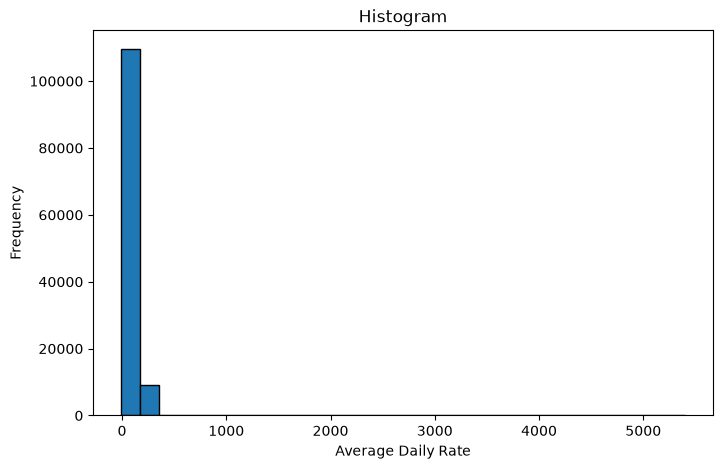

In [37]:
plt.figure(figsize=(8,5))

plt.hist(df["Avg Daily Rate"],
         bins=30,
         edgecolor="black")

plt.xlabel("Average Daily Rate")
plt.ylabel("Frequency")
plt.title("Histogram")

plt.show()

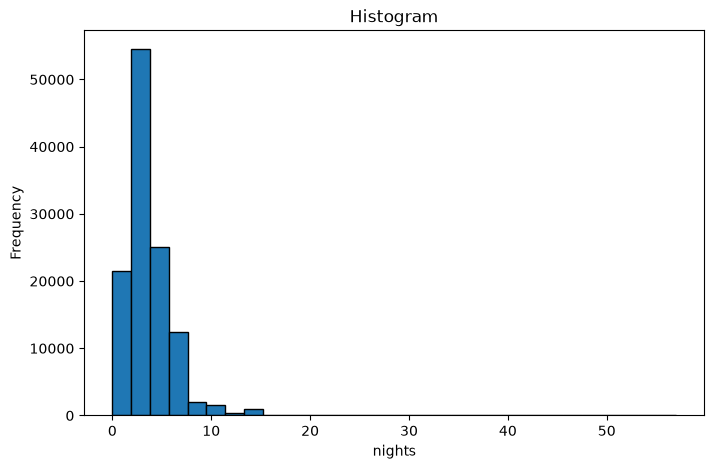

In [38]:
plt.figure(figsize=(8,5))

plt.hist(df["Nights"],
         bins=30,
         edgecolor="black")

plt.xlabel("nights")
plt.ylabel("Frequency")
plt.title("Histogram")

plt.show()

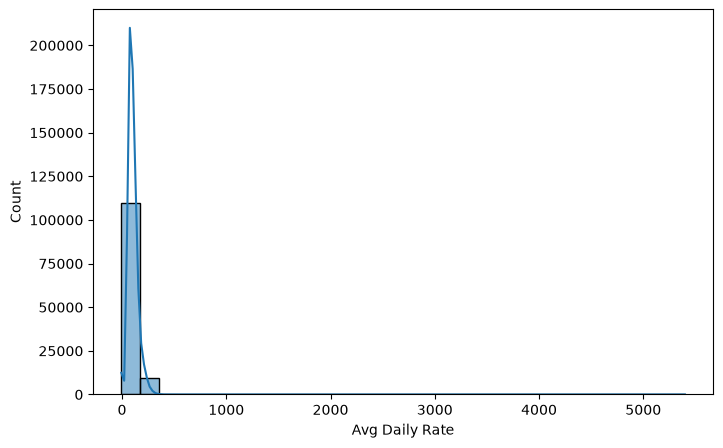

In [39]:
plt.figure(figsize=(8,5))

sns.histplot(df["Avg Daily Rate"],
             bins=30,
             kde=True)

plt.show()

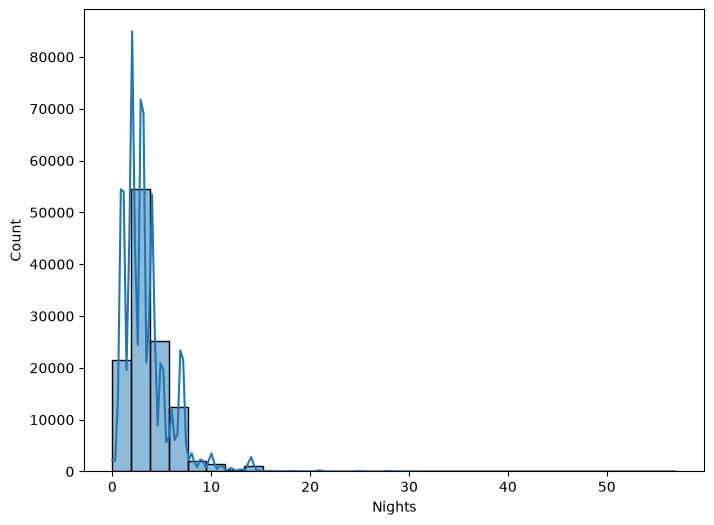

In [42]:
plt.figure(figsize=(8,6))
sns.histplot(df["Nights"],
             bins=30,
             kde=True)
plt.show()

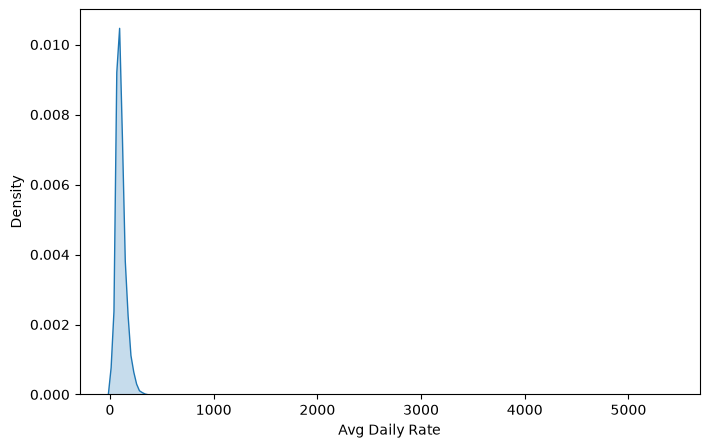

In [43]:
plt.figure(figsize=(8,5))

sns.kdeplot(df["Avg Daily Rate"],
            fill=True)

plt.show()

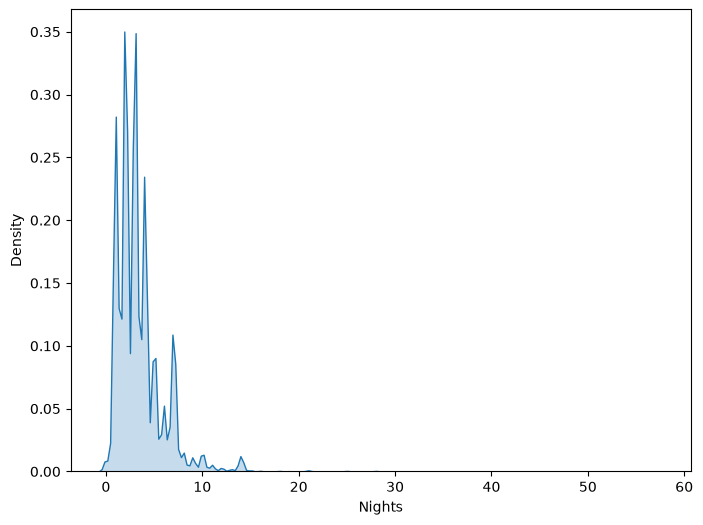

In [46]:
plt.figure(figsize=(8,6))
sns.kdeplot(df["Nights"],
             fill=True)
plt.show()

In [47]:
from scipy.stats import skew
from scipy.stats import kurtosis
from scipy.stats import zscore

In [48]:
df["Avg Daily Rate"].skew()

np.float64(10.598351194342209)

In [49]:
df["Nights"].skew()

np.float64(3.1275878874569565)

In [50]:
df["Avg Daily Rate"].kurt()

np.float64(1021.1514845392996)

In [51]:
df["Nights"].kurt()

np.float64(23.83836697022628)

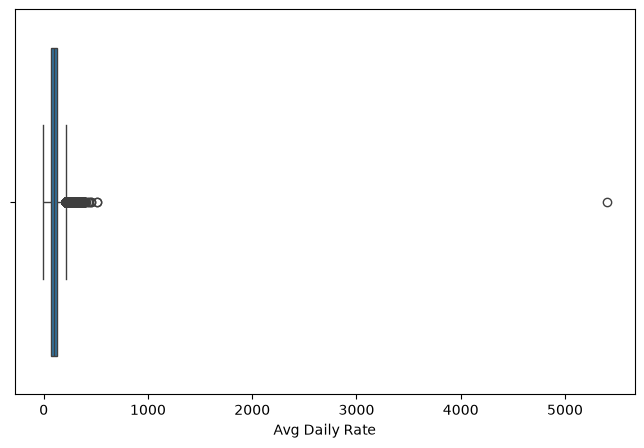

In [52]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df["Avg Daily Rate"])

plt.show()

In [57]:
Q1 = df["Avg Daily Rate"].quantile(0.25)

Q3 = df["Avg Daily Rate"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR

upper = Q3 + 1.5 * IQR

print("Lower Limit:", lower)
print("Upper Limit:", upper)

Lower Limit: -14.0
Upper Limit: 210.0


In [58]:
outliers = df[
    (df["Avg Daily Rate"] < lower) |
    (df["Avg Daily Rate"] > upper)
]

outliers

,Booking ID,Hotel,Booking Date,Arrival Date,Lead Time,Nights,Guests,Distribution Channel,Customer Type,Country,Deposit Type,Avg Daily Rate,Status,Status Update,Cancelled (0/1),Revenue,Revenue Loss
140,141,Resort,2015-05-22,2015-07-05,44,2,3,Online Travel Agent,Transient,Portugal,No Deposit,225.00,Check-Out,2015-07-07,Not Cancelled,450.00,0.0
303,304,Resort,2015-04-23,2015-07-11,79,8,4,Direct,Transient,Portugal,No Deposit,213.75,Check-Out,2015-07-19,Not Cancelled,1710.00,0.0
396,397,Resort,2014-08-31,2015-07-14,317,6,4,Online Travel Agent,Transient,Portugal,No Deposit,230.67,Check-Out,2015-07-20,Not Cancelled,1384.02,0.0
412,413,Resort,2015-06-08,2015-07-15,37,8,4,Online Travel Agent,Transient,United Kingdom,No Deposit,216.13,Check-Out,2015-07-23,Not Cancelled,1729.04,0.0
523,524,Resort,2015-07-18,2015-07-18,0,1,4,Direct,Transient,Portugal,No Deposit,249.00,Check-Out,2015-07-19,Not Cancelled,249.00,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119251,119252,City,2017-04-09,2017-08-27,140,5,4,Online Travel Agent,Transient,Austria,No Deposit,235.00,Check-Out,2017-09-01,Not Cancelled,1175.00,0.0
119289,119290,City,2017-08-05,2017-08-30,25,3,3,Online Travel Agent,Transient,Italy,No Deposit,236.33,Check-Out,2017-09-02,Not Cancelled,708.99,0.0
119339,119340,City,2017-05-11,2017-08-29,110,5,3,Direct,Transient,Italy,No Deposit,229.00,Check-Out,2017-09-03,Not Cancelled,1145.00,0.0
119365,119366,City,2017-07-04,2017-08-27,54,8,1,Direct,Transient,Japan,No Deposit,266.75,Check-Out,2017-09-04,Not Cancelled,2134.00,0.0


In [59]:
len(outliers)

3883

In [60]:
df["Z_score"] = zscore(df["Avg Daily Rate"])

In [61]:
df[abs(df["Z_score"]) > 3]

,Booking ID,Hotel,Booking Date,Arrival Date,Lead Time,Nights,Guests,Distribution Channel,Customer Type,Country,Deposit Type,Avg Daily Rate,Status,Status Update,Cancelled (0/1),Revenue,Revenue Loss,Z_score
803,804,Resort,2015-06-08,2015-07-30,52,3,4,Offline Travel Agent,Transient,Spain,No Deposit,280.74,Check-Out,2015-07-30,Not Cancelled,842.22,0.0,3.540316
925,926,Resort,2015-07-28,2015-08-06,9,3,4,Online Travel Agent,Transient,Spain,No Deposit,268.00,Check-Out,2015-08-09,Not Cancelled,804.00,0.0,3.287973
936,937,Resort,2015-06-19,2015-08-07,49,2,4,Online Travel Agent,Transient,Portugal,No Deposit,267.00,Canceled,2015-06-22,Cancelled,0.00,-534.0,3.268166
943,944,Resort,2015-08-03,2015-08-07,4,4,4,Online Travel Agent,Transient,Portugal,No Deposit,277.50,Canceled,2015-08-04,Cancelled,0.00,-1110.0,3.476141
973,974,Resort,2015-05-25,2015-08-08,75,7,4,Direct,Transient,Portugal,No Deposit,276.43,Check-Out,2015-08-15,Not Cancelled,1935.01,0.0,3.454947
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119126,119127,City,2017-04-15,2017-08-23,130,7,4,Direct,Transient,France,No Deposit,300.00,Check-Out,2017-08-30,Not Cancelled,2100.00,0.0,3.921802
119140,119141,City,2017-07-06,2017-08-27,52,3,3,Online Travel Agent,Transient,Germany,No Deposit,258.00,Check-Out,2017-08-30,Not Cancelled,774.00,0.0,3.089901
119144,119145,City,2017-08-24,2017-08-29,5,1,4,Online Travel Agent,Transient,Germany,No Deposit,259.00,Check-Out,2017-08-30,Not Cancelled,259.00,0.0,3.109708
119151,119152,City,2017-08-29,2017-08-29,0,1,4,Direct,Transient,Netherlands,No Deposit,270.00,Check-Out,2017-08-30,Not Cancelled,270.00,0.0,3.327587


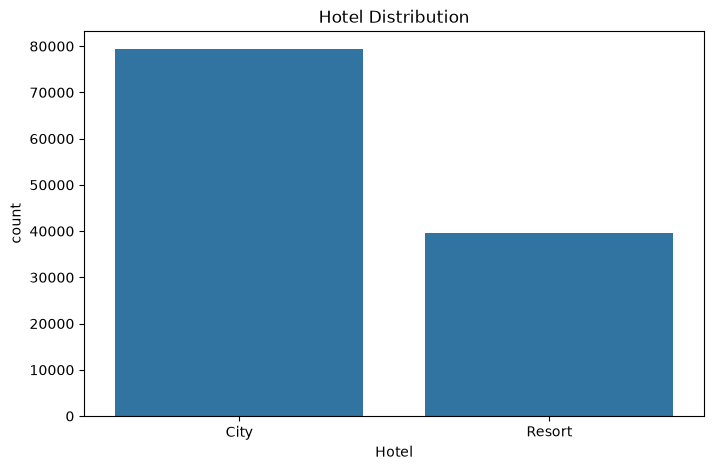

In [62]:
plt.figure(figsize=(8,5))

sns.countplot(data=df,
              x="Hotel")

plt.title("Hotel Distribution")

plt.show()   #for categorical Analysis (Univariat analysis)

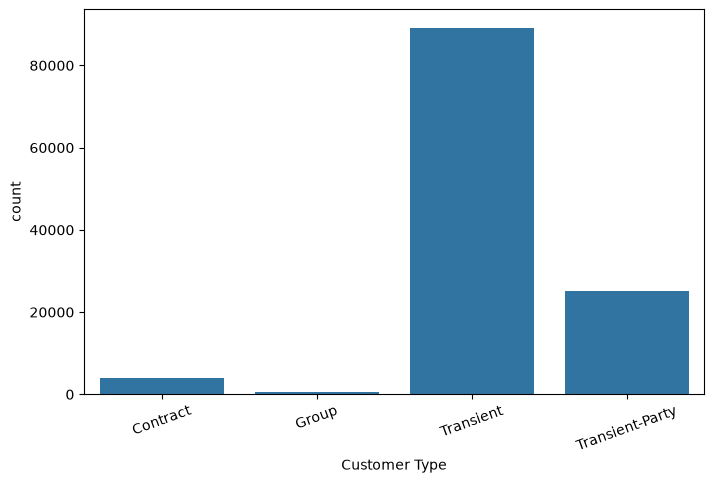

In [63]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Customer Type"
)

plt.xticks(rotation=20)

plt.show()

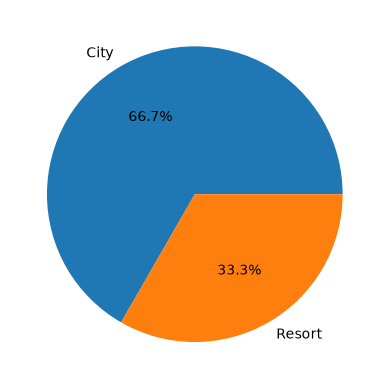

In [64]:
df["Hotel"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.ylabel("")

plt.show()

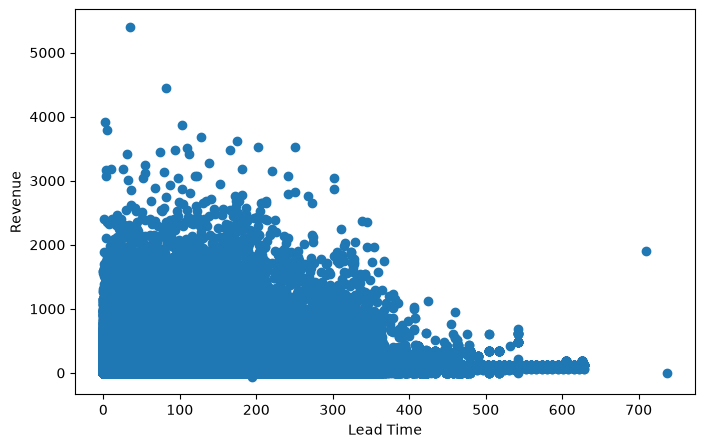

In [65]:
plt.figure(figsize=(8,5))

plt.scatter(
df["Lead Time"],
df["Revenue"]
)

plt.xlabel("Lead Time")

plt.ylabel("Revenue")

plt.show()

           Lead Time    Nights    Guests   Revenue
Lead Time   1.000000  0.155912  0.069546  0.044240
Nights      0.155912  1.000000  0.114517  0.490503
Guests      0.069546  0.114517  1.000000  0.154577
Revenue     0.044240  0.490503  0.154577  1.000000


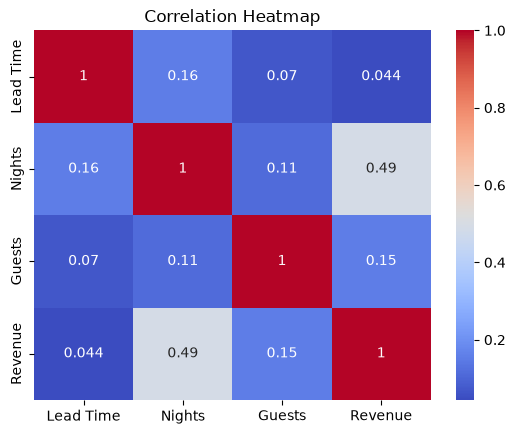

In [68]:
corr = df[['Lead Time', 'Nights', 'Guests', 'Revenue']].corr()
print(corr)

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()